Simple EDA

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('Data/gym.csv')

In [3]:
df

,member_id,visit_date,age,gender,membership_type,workout_type,workout_duration_minutes,calories_burned,check_in_time,attendance_status
0,1,2024-10-11,64,Other,Annual,HIIT,28,171,20:04,Absent
1,2,2024-06-01,65,Female,Quarterly,Strength Training,72,650,19:17,Absent
2,3,2024-06-13,45,Male,Quarterly,Cardio,70,633,7:24,Absent
3,4,2024-02-05,35,Female,Monthly,CrossFit,64,362,7:18,Absent
4,5,2024-07-13,26,Female,Quarterly,Yoga,31,262,11:22,Absent
...,...,...,...,...,...,...,...,...,...,...
2595,2596,2024-07-20,64,Female,Quarterly,Yoga,63,443,19:07,Absent
2596,2597,2024-05-13,22,Other,Quarterly,CrossFit,32,282,8:39,Present
2597,2598,2024-04-27,44,Male,Quarterly,CrossFit,94,875,22:49,Present
2598,2599,2024-12-20,62,Male,Annual,HIIT,58,303,10:38,Present


In [4]:
df.shape

(2600, 10)

The dataset has 2600 rows and 10 columns

Printing the names of the coulumns

In [5]:
df.columns

Index(['member_id', 'visit_date', 'age', 'gender', 'membership_type',
       'workout_type', 'workout_duration_minutes', 'calories_burned',
       'check_in_time', 'attendance_status'],
      dtype='object')

In [6]:
df.count(df.isnull==False)

member_id                   2600
visit_date                  2600
age                         2600
gender                      2600
membership_type             2600
workout_type                2600
workout_duration_minutes    2600
calories_burned             2600
check_in_time               2600
attendance_status           2600
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   member_id                 2600 non-null   int64 
 1   visit_date                2600 non-null   object
 2   age                       2600 non-null   int64 
 3   gender                    2600 non-null   object
 4   membership_type           2600 non-null   object
 5   workout_type              2600 non-null   object
 6   workout_duration_minutes  2600 non-null   int64 
 7   calories_burned           2600 non-null   int64 
 8   check_in_time             2600 non-null   object
 9   attendance_status         2600 non-null   object
dtypes: int64(4), object(6)
memory usage: 203.3+ KB


No null values

In [8]:
df[df['age'] == 45].count()

member_id                   47
visit_date                  47
age                         47
gender                      47
membership_type             47
workout_type                47
workout_duration_minutes    47
calories_burned             47
check_in_time               47
attendance_status           47
dtype: int64

In [9]:
#df_new = df.drop(df['age']==45)

Checking the datatypes of the data

In [10]:
df.dtypes

member_id                    int64
visit_date                  object
age                          int64
gender                      object
membership_type             object
workout_type                object
workout_duration_minutes     int64
calories_burned              int64
check_in_time               object
attendance_status           object
dtype: object

In [11]:
#df[df['visit_date']].to_datetime

Grouping by

In [12]:
df_by_gender = df.groupby(['gender'])['workout_duration_minutes'].mean()

In [13]:
df_by_gender

gender
Female    69.391648
Male      69.897767
Other     71.215527
Name: workout_duration_minutes, dtype: float64

In [14]:
df_by_workout_type = df.groupby(['workout_type'])['calories_burned'].mean()

In [15]:
df_by_workout_type

workout_type
Cardio               519.152294
CrossFit             532.453831
HIIT                 505.757692
Strength Training    540.626118
Yoga                 519.603854
Name: calories_burned, dtype: float64

In [16]:
df_by_workout_type = df_by_workout_type.reset_index()

In [17]:
df_by_workout_type

,workout_type,calories_burned
0,Cardio,519.152294
1,CrossFit,532.453831
2,HIIT,505.757692
3,Strength Training,540.626118
4,Yoga,519.603854


In [18]:
import matplotlib.pyplot as plt

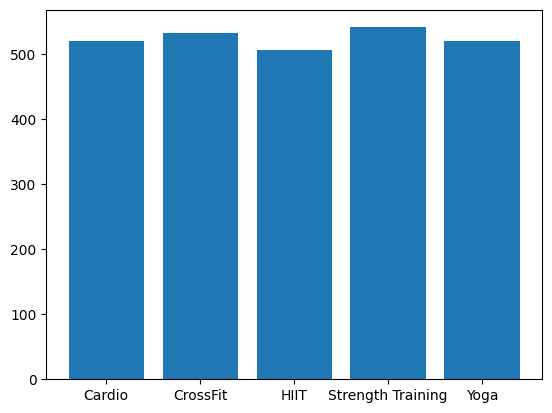

In [19]:
x = df_by_workout_type['workout_type']
y = df_by_workout_type['calories_burned']

fig, ax = plt.subplots()
ax.bar(x,y)
plt.show()

In [20]:
df_by_workout_type_duration = df.groupby(['workout_type'])['workout_duration_minutes'].mean()

In [21]:
df_by_workout_type_duration = df_by_workout_type_duration.reset_index()
df_by_workout_type_duration

,workout_type,workout_duration_minutes
0,Cardio,69.462385
1,CrossFit,70.821218
2,HIIT,68.080769
3,Strength Training,71.835420
4,Yoga,70.578158


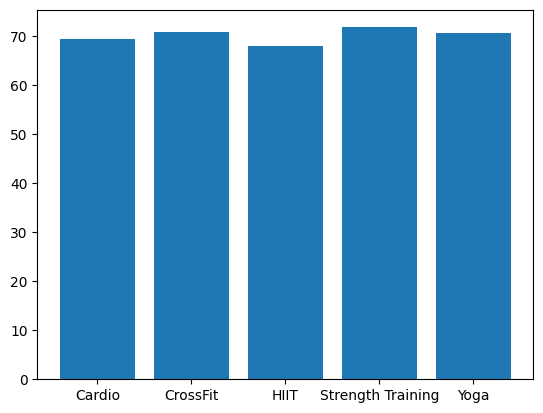

In [23]:
x = df_by_workout_type_duration['workout_type']
y = df_by_workout_type_duration['workout_duration_minutes']

fig, ax = plt.subplots()
plt.bar(x,y)
plt.show()

In [24]:
df_by_gender = df.groupby(['gender'])['workout_type'].value_counts()

In [25]:
df_by_gender

gender  workout_type     
Female  Cardio               197
        HIIT                 181
        Strength Training    179
        CrossFit             173
        Yoga                 156
Male    Strength Training    180
        Cardio               179
        HIIT                 178
        CrossFit             163
        Yoga                 151
Other   Strength Training    200
        CrossFit             173
        Cardio               169
        HIIT                 161
        Yoga                 160
Name: count, dtype: int64

In [40]:
df_by_membership_type = df.groupby(['membership_type'])['membership_type'].value_counts()

In [41]:
df_by_membership_type

membership_type
Annual       903
Monthly      856
Quarterly    841
Name: count, dtype: int64

### Insights 

1. The duration of the workout does not depend on the gender: Female-69.391648, Male-69.897767, Other-71.215527
2. All workout types burn over 500 calories on average but strenght training burns the most calories on average
3. On average strenght training is the longest in durations
4. Strenght training is the most popular for males and others while cardio is the most popular for females
5. Most popular subscription type is 'Annual'